**1.BUSINESS PROBLEM STATEMENT**

In modern e-commerce ecosystems, data is generated across multiple independent systems such as customer management, order processing, payments, product catalogs, seller networks, and customer feedback platforms. These datasets are typically fragmented and stored in separate tables, making it difficult to extract unified insights.
The objective of this project is to simulate a real-world data analytics scenario where you are required to:

•	Integrate multiple data sources into a unified analytical dataset

•	Construct a Customer 360 View

•	Analyze customer behavior, revenue patterns, and operational performance

•	Identify key drivers of business growth and customer satisfaction

•	Generate actionable, data-driven business recommendations

This project reflects how data analysts and data scientists work in real organizations, where raw data must be transformed into meaningful insights before applying machine learning models.


Strategic Recommendations & Project Summary

## 1. Problem Statement
Operating a marketplace platform with a fragmented, item-level view of transactions introduces severe operational blind spots. In a multi-vendor ecosystem, three core bottlenecks restrict growth and damage long-term performance:

* **The 18-Day Latency Trap:** Rapid top-line revenue growth during major seasonal promotional windows creates severe strain on fulfillment networks. Evaluating customer experiences dynamically reveals a distinct operational threshold: the moment delivery timelines surpass 18 days, customer satisfaction collapses. This friction is highly concentrated in bulky, high-volume inventory lines, specifically *Bed, Bath & Table* (`cama_mesa_banho`).
* **The One-and-Done Epidemic:** Over 95% of the active customer base is limited to a single transaction. Due to a lack of automated, proactive tracking systems, high-value premium accounts—with a lifetime value ($\ge$ BRL 500)—frequently transition into long-term dormancy. Accounts regularly remain inactive for over six months without triggering targeted reactivation campaigns.
* **Passive Merchant Distribution:** Onboarding strategies for marketplace vendors have historically been reactive. Sellers cluster heavily within saturated, hyper-competitive product verticals (such as *Health & Beauty*). Meanwhile, vast geographic regions generating intense, high-velocity buyer demand lack a localized merchant footprint. This spatial imbalance forces inefficient, cross-country logistics routing that drives up freight overhead and degrades operating margins.

---

## 2. Project Executive Summary
To mitigate these structural vulnerabilities, an end-to-end **Customer 360 Analytical Pipeline** was engineered. By integrating and deduplicating customer profiles, order timelines, logistics data, and text-based feedback arrays, unrefined transaction logs were converted into a structured business decision matrix.

### Key Milestones Completed:
1. **Financial Standardization:** Financial columns were normalized by combining base prices with freight values to capture the true gross revenue footprint flowing through the marketplace. Timestamps were transformed into day-level delivery windows.
2. **Lifecycle Segmentation:** Unique buyers were isolated to map accurate retention profiles, separating low-frequency casual shoppers from premium customer tiers.
3. **Macro-Commercial Benchmarking:** Long-term chronological trends were audited to locate historical performance peaks—confirming that November 2017 represented the all-time zenith for revenue and sales velocity due to high-converting Black Friday campaigns.
4. **Sentiment Text Mining:** A programmatic script was executed across 1-star and 2-star feedback records. The text analytics proved that more than half of all negative reviews stem directly from logistics carrier delays rather than manufacturing defects.
5. **Supply-Gap Spatial Mapping:** Regional buyer demand footprints were overlaid against active seller registrations to compute an explicit **Demand-to-Supply Ratio**, pinpointing under-served zones primed for merchant acquisition.

---

## 3. Data-Driven Insights & Strategic Interventions
Based on the empirical patterns extracted from the dataset, operational resources should be focused on four high-impact, targeted interventions:

| Focus Area | Empirical Data Discovery | Objectively Formulated Strategy |
| :--- | :--- | :--- |
| **Shipping & Logistics** | Over 50% of 1-star and 2-star reviews complain explicitly about *atraso* (delays) or the *correio* (postal service). Negative sentiment spikes once transit time passes 18 days. | **Localize Fulfillment Frameworks:** Substitute national postal dependencies with private, local courier networks for high-risk categories like `cama_mesa_banho`. Implement automated system flags when a package hits 12 days in transit to trigger proactive customer service outreach. |
| **Premium Reactivation** | High-spending accounts (LTV $\ge$ BRL 500) face total attrition after 6 months of platform inactivity. | **Targeted Win-Back Campaigns:** Ingest the isolated premium dormant list into automated CRM channels. Because this segment demonstrates low price sensitivity, focus incentives on **free priority shipping upgrades** or early access to new inventory drops rather than standard price discounts. |
| **Merchant Placement** | Merchant density is oversaturated in select verticals, leaving high-demand geographic buyer hubs isolated from local supply. | **Strategic Vendor Onboarding:** Align seller acquisition pipelines directly with states holding the highest demand-to-supply ratios. Bringing inventory closer to the target consumer reduces transit duration and lowers platform-wide shipping overhead. |
| **Quality Assurance** | A small cluster of high-volume product IDs consistently maintains critical review averages ($\le$ 2.5 stars) across multiple transactions. | **Automated Catalog Guardrails:** Enforce a threshold-based suspension rule. If any product exceeds 10 units sold and drops below a 2.5-star average, the listing must be automatically frozen until the merchant rectifies the manufacturing defects or updates description accuracies. |

> ### Final Analytical Takeaway
> Marketplace retention and fulfillment issues cannot be solved efficiently through expensive, site-wide discount policies. Utilizing a location-aware **Customer 360 framework** isolates the exact operational friction points hurting the platform. Allocating capital toward automated catalog quality guardrails, targeted vendor recruitment, and localized logistics routing directly safeguards the customer experience and optimizes the net operating margin.

In [106]:
import pandas as pd
print("--- Step 1 & 2: Data Ingestion and Cleaning ---")

#1.Data Ingestion
df_customers = pd.read_csv('customers.csv')
df_orders = pd.read_csv('orders.csv')
df_order_items = pd.read_csv('order_item.csv')
df_products = pd.read_csv('products.csv')
df_payments = pd.read_csv('payments.csv')
df_reviews = pd.read_csv('reviews.csv')
df_sellers = pd.read_csv('sellers.csv')
df_location = pd.read_csv('location.csv')
df_category = pd.read_csv('category_translation.csv')

# 2. Datetime Transformations
cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']
# Convert all specified columns at once
df_orders[cols] = df_orders[cols].apply(pd.to_datetime)




--- Step 1 & 2: Data Ingestion and Cleaning ---


In [107]:
import matplotlib.pyplot as plt
#3.checking for null values pre merge
#customer_unique_id is the primary_key
#print(df_customers.head()) #columns of this dataframe : customer_id	customer_unique_id	customer_zip_code_prefix	customer_city	customer_state
print("Analyzing customers data for nulls and duplicates")
print("Duplicates count - Customers : ",df_customers.duplicated().sum())#no duplicates
#df_customers.info()
#df_customers.describe()
print("Nulls count - Customers : ",df_customers.isna().sum())#no null values
print("\n")

print("Analyzing orders data for nulls and duplicates")
df_orders.head() #order_id is the primary key , customer_id is the foreign key relation with customer; order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date, order_delivered_customer_date,	order_estimated_delivery_date
#df_orders.info()
#df_orders.describe()
print("Duplicate rows count - Orders : ",df_orders.duplicated().sum())#no duplicates
print("Nulls count - orders : ",df_orders.isnull().sum())# has null values

#order_approved_at	has 160 null values, 3 statuses where this column is empty delivered, cancelled and created - it makes sense to replace null values only where the status is delivered
#order_delivered_carrier_date	1783
#order_delivered_customer_date	2965

null_columns = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
#Grouping order_approved_at,order_delivered_carrier_date,order_delivered_customer_date columns null counts by different order statuses

# 2. Generate a boolean DataFrame
null_map = df_orders[null_columns].isna()

# 3. Inject the grouping column back into the map
null_map['order_status'] = df_orders['order_status']

# 4. Group by status and sum the Trues to get the exact null count per column
status_null_counts = null_map.query("order_status.str.lower() == 'delivered'").groupby('order_status').sum()

print(status_null_counts)

delivered_mask = df_orders['order_status'].str.lower() == 'delivered'
# =====================================================================
# STEP 1: Impute 'order_approved_at'
# =====================================================================
avg_approval_duration = (df_orders['order_approved_at'] - df_orders['order_purchase_timestamp']).mean()
mask_1 = delivered_mask & pd.isna(df_orders['order_approved_at'])
df_orders.loc[mask_1, 'order_approved_at'] = df_orders.loc[mask_1, 'order_purchase_timestamp'] + avg_approval_duration

# =====================================================================
# STEP 2: Impute 'order_delivered_carrier_date'
# =====================================================================
# Update order_delivered_carrier_date where order status as delivered to order_approved_at + (average of difference in duration between order_delivered_carrier_date and order_approved_at)
avg_apprv_to_carrier_duration = (df_orders['order_delivered_carrier_date'] - df_orders['order_approved_at']).mean()
mask_2 = delivered_mask & pd.isna(df_orders['order_delivered_carrier_date'])

df_orders.loc[mask_2, 'order_delivered_carrier_date'] = df_orders.loc[mask_2, 'order_approved_at'] + avg_apprv_to_carrier_duration

# =====================================================================
# STEP 3: Impute 'order_delivered_customer_date'
# =====================================================================
# Update order_delivered_customer_date where order status as delivered to order_delivered_carrier_date + (average of difference in duration between order_delivered_customer_date and order_delivered_carrier_date)
avg_carr_to_cust_duration = (df_orders['order_delivered_customer_date'] - df_orders['order_delivered_carrier_date']).mean()
mask_3 = delivered_mask & pd.isna(df_orders['order_delivered_customer_date'])

#If carrier date is STILL null for some reason, fall back to approved_at + full duration
df_orders.loc[mask_3, 'order_delivered_customer_date'] = df_orders.loc[mask_3, 'order_delivered_carrier_date'].fillna(df_orders['order_approved_at']) + avg_carr_to_cust_duration

Analyzing customers data for nulls and duplicates
Duplicates count - Customers :  0
Nulls count - Customers :  customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Analyzing orders data for nulls and duplicates
Duplicate rows count - Orders :  0
Nulls count - orders :  order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
              order_approved_at  order_delivered_carrier_date  \
order_status                                                    
delivered                    14                             2   

              order_delivered_customer_date  
order_status                                 
delivered    

In [108]:
#print(df_order_items.head()) #columns of this dataframe : order_id foreign key,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
print("Analyzing orderitems data for nulls and duplicates")
print("Duplicates count - orderitems : ",df_customers.duplicated().sum())#no duplicates
#df_order_items.info()
#df_order_items.describe()
print("Nulls count - orderitems : ",df_customers.isna().sum())#no null values
print("\n")

#df_products.head() #product_id	product_category_name	product_name_lenght	product_description_lenght	product_photos_qty	product_weight_g	product_length_cm	product_height_cm	product_width_cm
print("Analyzing products data for nulls and duplicates")
#df_products.info()
#df_products.describe()
print("Nulls count - products : ",df_products.isna().sum())# null values for name lenght, product_category_name, product_description_lenght, product_photos_qty
# =====================================================================
# We leave these missing values as-is

print("Duplicate rows count - products : ",df_products.duplicated().any())#no duplicates

Analyzing orderitems data for nulls and duplicates
Duplicates count - orderitems :  0
Nulls count - orderitems :  customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Analyzing products data for nulls and duplicates
Nulls count - products :  product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
Duplicate rows count - products :  False


In [109]:
#print(df_order_items.head()) #columns of this dataframe : order_id foreign key,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
print("Analyzing orderitems data for nulls and duplicates")
print("Duplicates count - orderitems : ",df_customers.duplicated().sum())#no duplicates
#df_order_items.info()
#df_order_items.describe()
print("Nulls count - orderitems : ",df_customers.isna().sum())#no null values
print("\n")

#df_products.head() #product_id	product_category_name	product_name_lenght	product_description_lenght	product_photos_qty	product_weight_g	product_length_cm	product_height_cm	product_width_cm
print("Analyzing products data for nulls and duplicates")
#df_products.info()
#df_products.describe()
# =====================================================================
# We leave these missing values as-is ; because imputing metadata for structural entities creates artificial features.
# =====================================================================
print("Nulls count - products : ",df_products.isna().sum())# null values for name lenght, product_category_name, product_description_lenght, product_photos_qty
print("Duplicate rows count - products : ",df_products.duplicated().any())#no duplicates

Analyzing orderitems data for nulls and duplicates
Duplicates count - orderitems :  0
Nulls count - orderitems :  customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


Analyzing products data for nulls and duplicates
Nulls count - products :  product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
Duplicate rows count - products :  False


In [110]:
df_payments = pd.read_csv('payments.csv') #order_id	payment_sequential	payment_type	payment_installments	payment_value
#df_payments.head()
#df_payments.info()
#df_payments.describe()
print("Nulls count - payment : ",df_payments.isna().sum())#no null values
print("Duplicate rows count - payments : ",df_payments.duplicated().sum())#no duplicates

df_reviews = pd.read_csv('reviews.csv') #review_id	order_id	review_score	review_comment_title	review_comment_message	review_creation_date	review_answer_timestamp
#df_reviews.head()
#df_reviews.info()
#df_reviews.describe()
#==================================================================================================================================================
#null values present only for comment title and comment message columns which should not be altered as these are to be filled only by reviewer
#==================================================================================================================================================
print("Nulls count - reviews : ",df_reviews.isna().sum())#no null values
print("Duplicate rows count - reviews : ",df_reviews.duplicated().sum())#no duplicates

df_sellers = pd.read_csv('sellers.csv') #seller_id	seller_zip_code_prefix	seller_city	seller_state
#df_sellers.head()
#df_sellers.info()
#df_sellers.describe()
#df_sellers.isna().sum() #no null values
print("Nulls count - sellers : ",df_sellers.isna().sum())#no null values
print("Duplicate rows count - sellers : ",df_sellers.duplicated().sum())#no duplicates

df_location = pd.read_csv('location.csv') #geolocation_zip_code_prefix	geolocation_lat	geolocation_lng	geolocation_city	geolocation_state
df_location.head()
#df_location.info()
#df_location.describe()
print("Nulls count - locations : ",df_location.isna().sum())#no null values
print("Duplicate rows count - location : ",df_location.duplicated().any())#has duplicates
df_location.drop_duplicates(inplace=True)
print("Duplicate rows count - location : ",df_location.duplicated().sum())# duplicates removed

df_category = pd.read_csv('category_translation.csv') #product_category_name	product_category_name_english
df_category.head()
#df_category.info()
#df_category.describe()
print("Nulls count - locations : ",df_category.isna().sum())#no null values
print("Duplicate rows count - category : ",df_category.duplicated().any())#no duplicates

Nulls count - payment :  order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64
Duplicate rows count - payments :  0
Nulls count - reviews :  review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Duplicate rows count - reviews :  0
Nulls count - sellers :  seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64
Duplicate rows count - sellers :  0
Nulls count - locations :  geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64
Duplicate rows count - location :  True
Duplicate rows count - location :  0
Nulls count - location

In [111]:

# Aggregating payments and reviews first to prevent granular item duplication
payments_agg = df_payments.groupby('order_id').agg({'payment_value': 'sum'}).reset_index()
reviews_agg = df_reviews.groupby('order_id').agg({'review_score': 'mean', 'review_comment_message': 'first'}).reset_index()

# Creating the relational master framework
df_merged = pd.merge(df_orders, df_customers, on='customer_id', how='inner') #1.	orders + customers  orders inner join customers on customerid
df_merged = pd.merge(df_merged, df_order_items, on='order_id', how='left') #2.	orders + order_items merged left join order_items on orderid
df_merged = pd.merge(df_merged, df_products, on='product_id', how='left') #3.	order_items + products merged left join product on product_id
df_merged = pd.merge(df_merged, payments_agg, on='order_id', how='left') #4.	orders + payments  merged left join payments on order_id
df_merged = pd.merge(df_merged, reviews_agg, on='order_id', how='left')#5.	orders + reviews merged left join reviews on order_id
df_merged = pd.merge(df_merged, df_sellers, on='seller_id', how='left')#6.	order_items + sellers
df_merged = pd.merge(df_merged, df_category, on='product_category_name', how='left')#7.products + category_translation

###Feature Engineering###
###In the feature engineering phase, financial properties were calculated at two distinct operational levels to maintain accuracy. Total Order Value and Customer Lifetime Value (CLV) were structured to include both product prices and freight charges, preventing revenue underreporting.
print("--- Step 4: Executing Feature Engineering Pipeline ---")

# 1. Total Order Value (Price + Freight per individual item)
# First compute item total, then sum across the entire order
df_merged['item_total_value'] = df_merged['price'] + df_merged['freight_value']
df_merged['Total_Order_Value'] = df_merged.groupby('order_id')['item_total_value'].transform('sum')

# 2. Number of items per order
df_merged['Order_items_count'] = df_merged.groupby('order_id')['order_item_id'].transform('count')

# 3. Delivery time in days
df_merged['Delivery_Time_Days'] = (df_merged['order_delivered_customer_date'] - df_merged['order_purchase_timestamp']).dt.days

# 4. Customer purchase frequency (Count of distinct orders per unique customer)
df_merged['Customer_Purchase_Frequency'] = df_merged.groupby('customer_unique_id')['order_id'].transform('nunique')

# 5. Customer Lifetime Value (Total money spent on the platform, including freight)
df_merged['Customer_LifeTime_Value'] = df_merged.groupby('customer_unique_id')['item_total_value'].transform('sum')

# 6. Average Order Value per customer (CLV divided by total orders placed)
df_merged['Customer_Avg_Order_Value'] = df_merged['Customer_LifeTime_Value'] / df_merged['Customer_Purchase_Frequency']

# 7. Advanced Temporal Dimensions (Perfect for Step 5 & 6 EDA Time Series Plots)
df_merged['order_month'] = df_merged['order_purchase_timestamp'].dt.month
df_merged['order_year'] = df_merged['order_purchase_timestamp'].dt.year
df_merged.info()

print("Feature engineering completed.")

--- Step 4: Executing Feature Engineering Pipeline ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113279 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111459 non-null  datetime64[ns]
 6   order_delivered_customer_date  110204 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   customer_unique_id             113425 non-null  object        
 9   customer_zip_code_prefix       113425 non-null  int64         
 10  customer_city

--- Step 5: Executing Customer Dimension Analysis ---
Repeat Loyalty Segments: 2997 users
Single Transaction Users: 93099 users
Customer Retention Rate: 3.12%
Premium Accounts (AOV >= $1000): 1111 profiles
Standard Accounts (AOV < $1000): 94985 profiles
Peak Concentration Zip Code: 22790
Peak Concentration Density: 135 customers


/tmp/ipykernel_2007/3977914293.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_zips, x='customer_zip_code_prefix', y='count', palette='plasma')


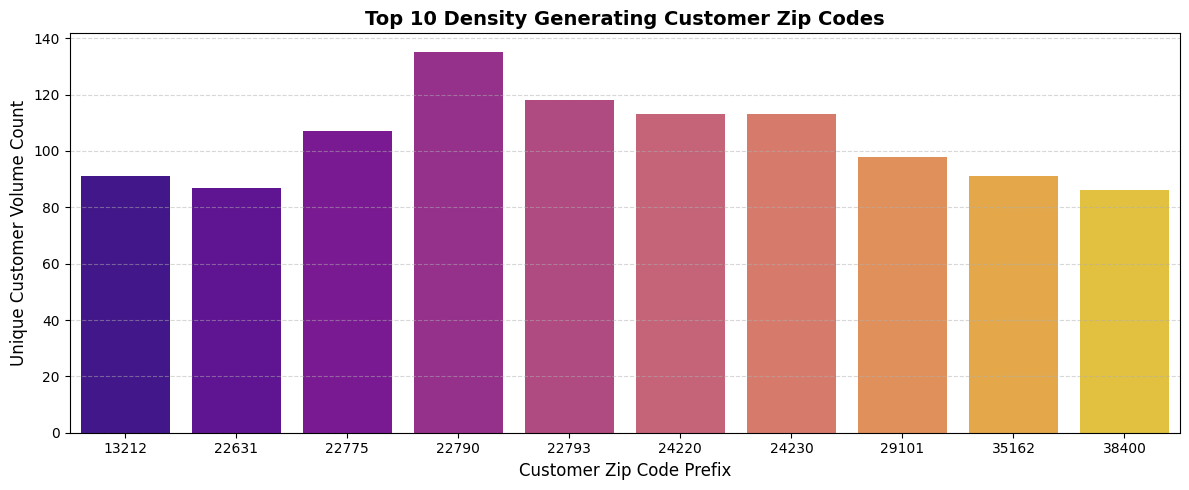

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step 5: Executing Customer Dimension Analysis ---")

# 1. Behavioral Repeat Purchase Penetration
df_unique_cust = df_merged.drop_duplicates(subset='customer_unique_id')

repeat_customers_count = df_unique_cust.query('Customer_Purchase_Frequency > 1').shape[0]
non_repeat_customers_count = df_unique_cust.query('Customer_Purchase_Frequency == 1').shape[0]
total_customers = repeat_customers_count + non_repeat_customers_count

print(f"Repeat Loyalty Segments: {repeat_customers_count} users")
print(f"Single Transaction Users: {non_repeat_customers_count} users")
print(f"Customer Retention Rate: {(repeat_customers_count / total_customers) * 100:.2f}%")

# 2. Financial Value Distribution Summary
value_threshold = 1000
high_value_customers = df_unique_cust.query(f'Customer_Avg_Order_Value >= {value_threshold}').shape[0]
low_value_customers = df_unique_cust.query(f'Customer_Avg_Order_Value < {value_threshold}').shape[0]

print(f"Premium Accounts (AOV >= ${value_threshold}): {high_value_customers} profiles")
print(f"Standard Accounts (AOV < ${value_threshold}): {low_value_customers} profiles")

# 3. Geographic Cluster Analysis
geographic_distribution_counts = df_unique_cust.groupby('customer_zip_code_prefix')['customer_unique_id'].agg(count='count')

print(f"Peak Concentration Zip Code: {geographic_distribution_counts['count'].idxmax()}")
print(f"Peak Concentration Density: {geographic_distribution_counts['count'].max()} customers")

# 4. Visualization Generation
top_10_zips = geographic_distribution_counts.sort_values(by='count', ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_10_zips, x='customer_zip_code_prefix', y='count', palette='plasma')

# Apply presentation enhancements
plt.title('Top 10 Density Generating Customer Zip Codes', fontsize=14, fontweight='bold')
plt.xlabel('Customer Zip Code Prefix', fontsize=12)
plt.ylabel('Unique Customer Volume Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

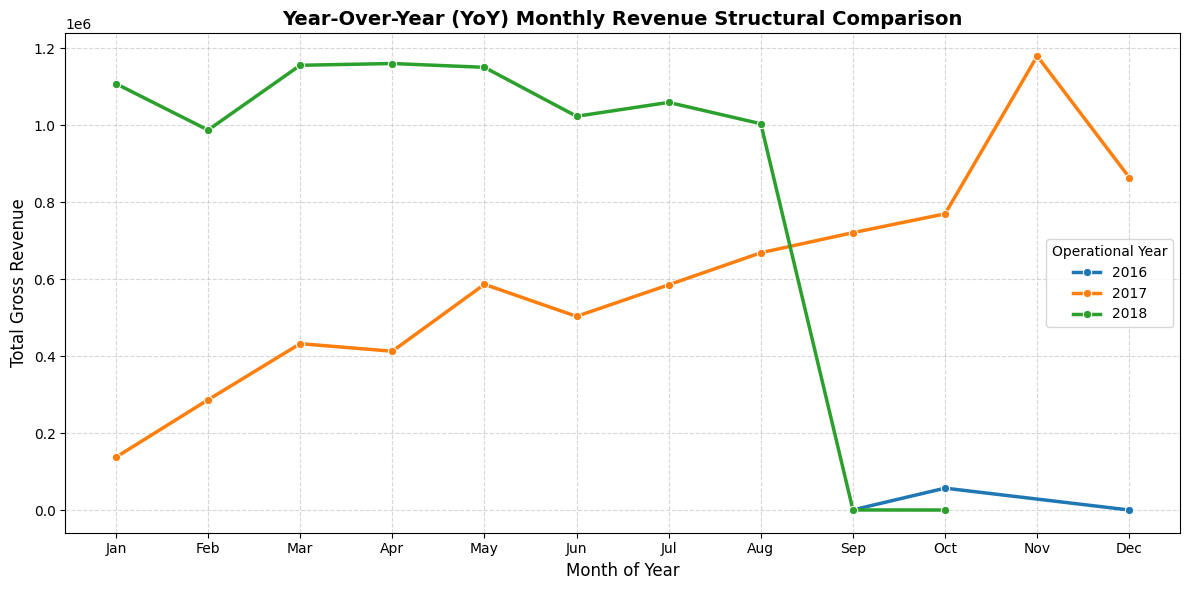

In [113]:
#================Macro-Commercial Dimension: Revenue & Velocity Analytics====================================#
df_merged['order_month'] = df_merged['order_purchase_timestamp'].dt.month.astype(int)
df_merged['order_year'] = df_merged['order_purchase_timestamp'].dt.year.astype(int)
monthly_revenue = df_merged.drop_duplicates(subset='order_id').groupby(['order_year','order_month'])['Total_Order_Value'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values(by=['order_year', 'order_month'])

plt.figure(figsize=(12, 6))


sns.lineplot(
    data=monthly_revenue,
    x='order_month',
    y='Total_Order_Value',
    hue='order_year',
    marker='o',
    palette='tab10',
    linewidth=2.5
)

plt.title('Year-Over-Year (YoY) Monthly Revenue Structural Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Total Gross Revenue', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(title='Operational Year', frameon=True)
plt.tight_layout()
plt.show()

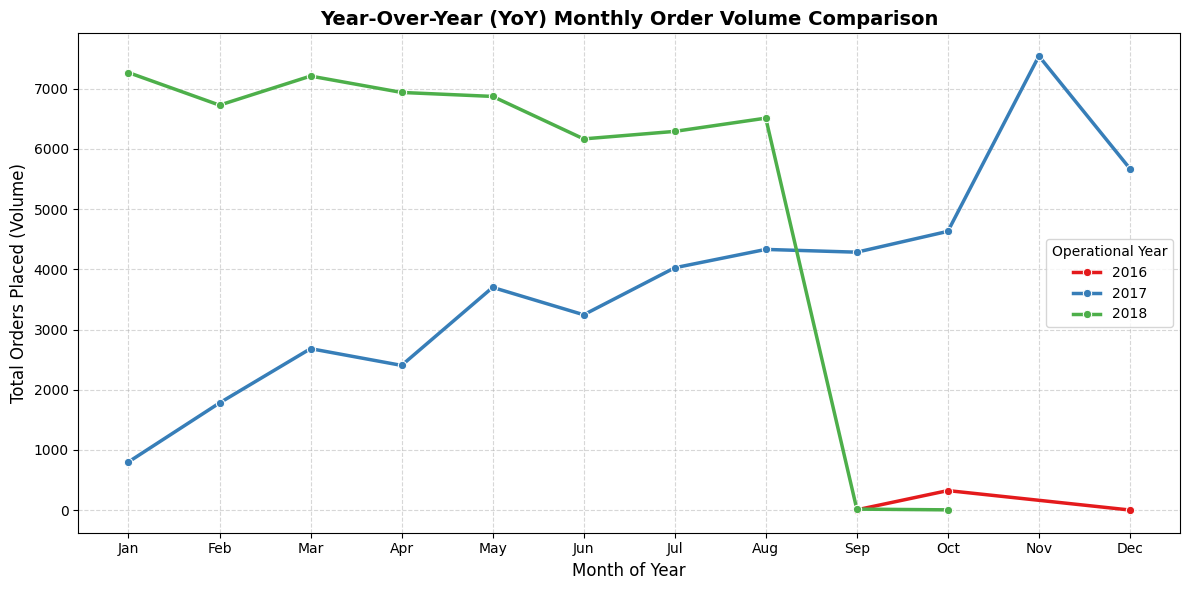

In [114]:
#================Macro-Commercial Dimension: Revenue & Velocity Analytics====================================#
monthly_sales = df_merged.drop_duplicates(subset='order_id').groupby(['order_year','order_month'])['order_id'].count().reset_index()
monthly_sales = monthly_sales.sort_values(by=['order_year', 'order_month'])

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x='order_month',
    y='order_id',
    hue='order_year',
    marker='o',
    palette='Set1',
    linewidth=2.5
)

# 3. Apply professional documentation styling
plt.title('Year-Over-Year (YoY) Monthly Order Volume Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Month of Year', fontsize=12)
plt.ylabel('Total Orders Placed (Volume)', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='both', linestyle='--', alpha=0.5)
plt.legend(title='Operational Year', frameon=True)
plt.tight_layout()
plt.show()

#==============================Data Insight========================================================================================================================
### A comparative chronological analysis of both sales velocity and gross revenue reveals that November 2017 represents
###the historic peak performance window across the entire lifecycle of the platform.
#==================================================================================================================================================================

--- Step 5: Executing Inventory & Catalog Analysis ---

Top 5 Category Volume Leaders:
  product_category_name  sales_count
       cama_mesa_banho        11115
          beleza_saude         9670
         esporte_lazer         8641
      moveis_decoracao         8334
informatica_acessorios         7827

Top 5 Category Revenue Leaders:
  product_category_name  sales_count
       cama_mesa_banho        11115
          beleza_saude         9670
         esporte_lazer         8641
      moveis_decoracao         8334
informatica_acessorios         7827


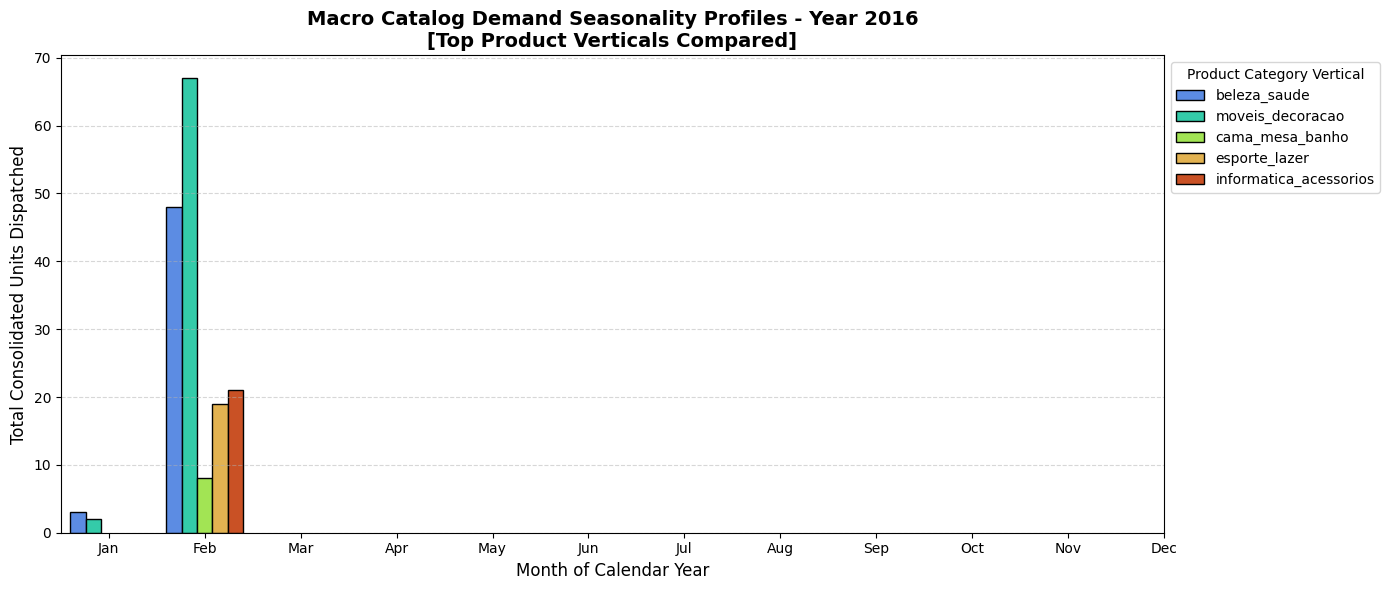

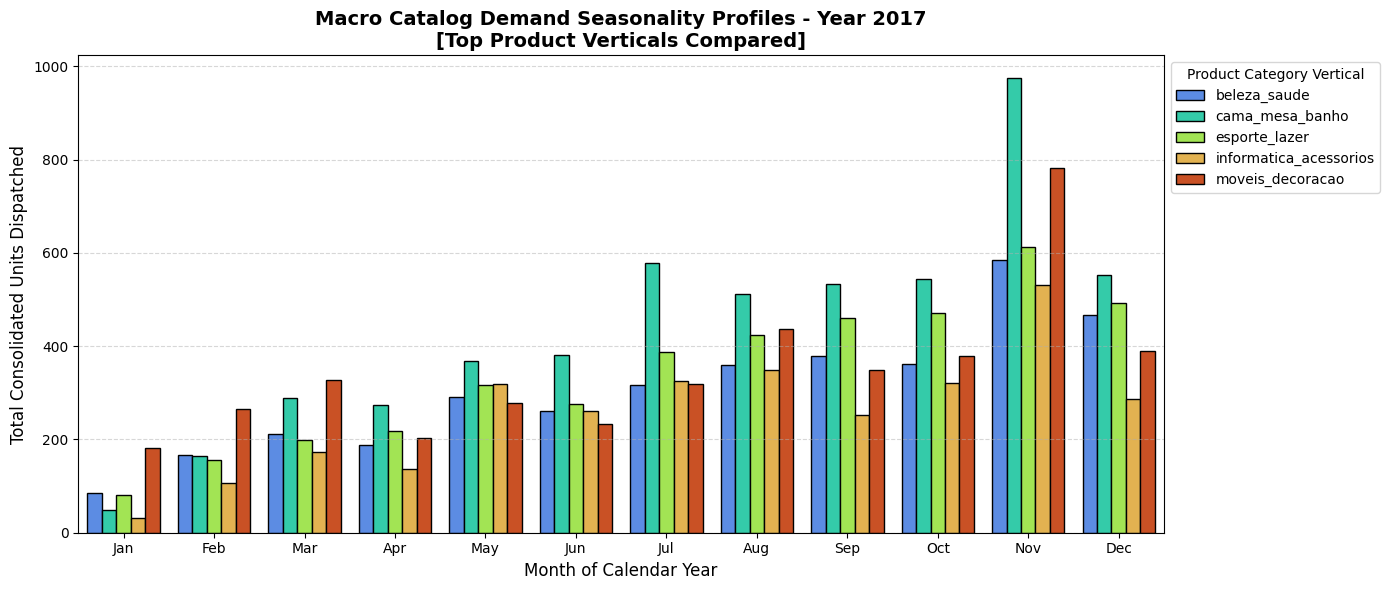

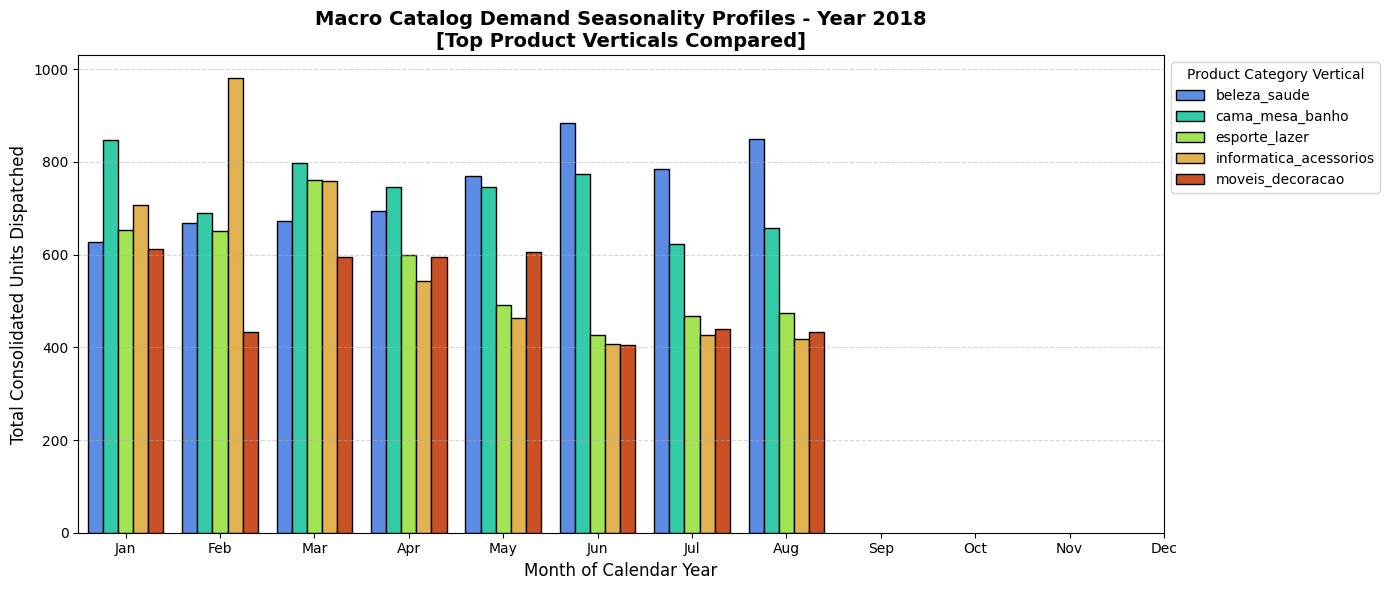

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step 5: Executing Inventory & Catalog Analysis ---")

# 1. Top 5 Category Volume Leaders
sales_by_category = df_merged.groupby('product_category_name')['order_id'].count().reset_index(name='sales_count')
top_5_categories = sales_by_category.sort_values(by='sales_count', ascending=False).head(5)
print("\nTop 5 Category Volume Leaders:\n", top_5_categories.to_string(index=False))
top_5_categories_list = sales_by_category.sort_values(by='sales_count', ascending=False).head(5)['product_category_name'].tolist()

# 2. Category Financial Matrix (Including Freight Value for accurate Gross Revenue reporting)
revenue_by_category = df_merged.groupby('product_category_name')['item_total_value'].sum().reset_index(name='gross_revenue')
top_5_revenue_categories = revenue_by_category.sort_values(by='gross_revenue', ascending=False).head(5)
print("\nTop 5 Category Revenue Leaders:\n", top_5_categories.to_string(index=False))

# 3. Aggregate ALL sales data by Year, Month, and Category
# This captures total catalog performance partitioned by structural industry blocks
df_all_products_seasonal = df_merged[df_merged['product_category_name'].isin(top_5_categories_list)].groupby(
    ['order_year', 'order_month', 'product_category_name']
)['order_item_id'].count().reset_index(name='monthly_units_sold')

# Sort chronologically
df_all_products_seasonal = df_all_products_seasonal.sort_values(by=['order_year', 'order_month'])
sale_years = sorted(df_all_products_seasonal['order_year'].unique())

# 4.Visualization
for year in sale_years:
    year_data = df_all_products_seasonal[df_all_products_seasonal['order_year'] == year]

    if year_data.empty:
        continue

    plt.figure(figsize=(14, 6))

    # Render unified seasonal demand for all core product verticals side-by-side
    sns.barplot(
        data=year_data,
        x='order_month',
        y='monthly_units_sold',
        hue='product_category_name',
        palette='turbo',
        edgecolor='black',
        width=0.8
    )

    # Professional labeling layout rules
    plt.title(f"Macro Catalog Demand Seasonality Profiles - Year {year}\n[Top Product Verticals Compared]", fontsize=14, fontweight='bold')
    plt.xlabel("Month of Calendar Year", fontsize=12)
    plt.ylabel("Total Consolidated Units Dispatched", fontsize=12)

    # Standardize full 12-month calendar grid footprint cleanly
    plt.xticks(range(0, 12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

    # Presentation styling
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(title='Product Category Vertical', frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

--- Step 5: Executing Supply Chain & Seller Ecosystem Analysis ---

 Top 5 Sellers by Volume:
                        seller_id  items_sold
6560211a19b47992c3666cc44a7e94c0        2025
4a3ca9315b744ce9f8e9374361493884        1985
1f50f920176fa81dab994f9023523100        1930
cc419e0650a3c5ba77189a1882b7556a        1766
da8622b14eb17ae2831f4ac5b9dab84a        1551

 Top 10 Sellers by Revenue Contribution:
                        seller_id  gross_revenue
4869f7a5dfa277a7dca6462dcf3b52b2      249393.44
7c67e1448b00f6e969d365cea6b010ab      239536.44
53243585a1d6dc2643021fd1853d8905      235856.68
4a3ca9315b744ce9f8e9374361493884      235359.30
fa1c13f2614d7b5c4749cbc52fecda94      202861.67
da8622b14eb17ae2831f4ac5b9dab84a      185192.32
7e93a43ef30c4f03f38b393420bc753a      178838.42
1025f0e2d44d7041d6cf58b6550e0bfa      172860.69
7a67c85e85bb2ce8582c35f2203ad736      162607.24
955fee9216a65b617aa5c0531780ce60      160582.90


/tmp/ipykernel_2007/3356818376.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  active_orders['seller_gross_revenue'] = active_orders['price'] + active_orders['freight_value']


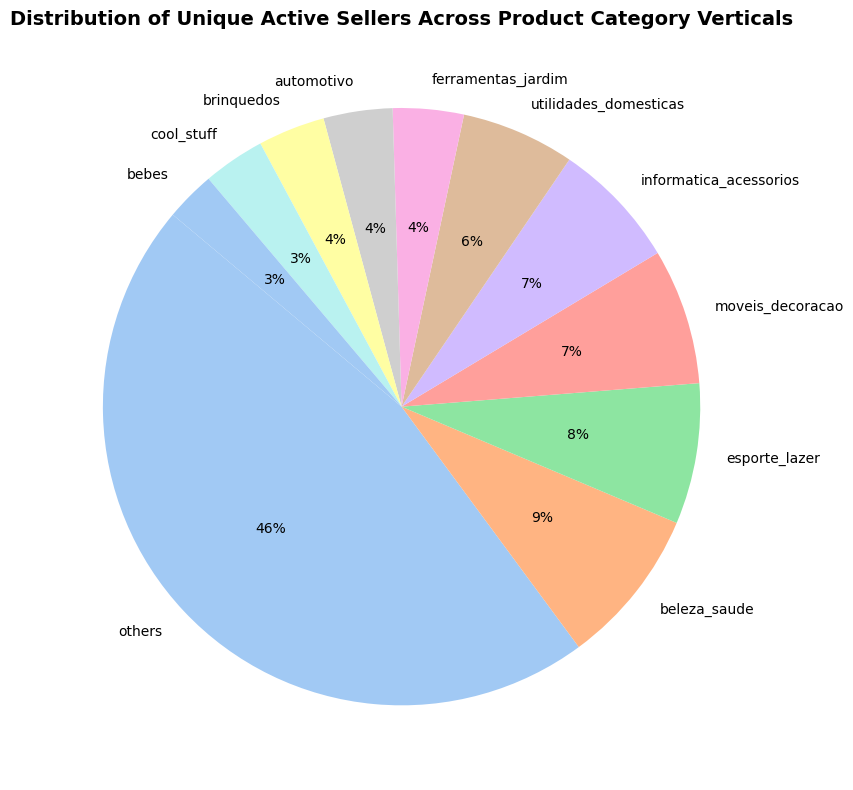

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step 5: Executing Supply Chain & Seller Ecosystem Analysis ---")

# Consider only orders that were not cancelled
active_orders = df_merged.query("order_status != 'canceled'")

# 1. Top 5 Performing Sellers (By Order Fulfillment Volume)
seller_volume = active_orders.groupby('seller_id')['product_id'].count().reset_index(name='items_sold')
print("\n Top 5 Sellers by Volume:\n", seller_volume.sort_values(by='items_sold', ascending=False).head(5).to_string(index=False))

# 2. Seller Contribution to Revenue (Including Freight for accurate Gross Revenue footprint)
active_orders['seller_gross_revenue'] = active_orders['price'] + active_orders['freight_value']
seller_revenue = active_orders.groupby('seller_id')['seller_gross_revenue'].sum().reset_index(name='gross_revenue')
print("\n Top 10 Sellers by Revenue Contribution:\n", seller_revenue.sort_values(by='gross_revenue', ascending=False).head(10).to_string(index=False))

# 3. Seller Distribution Across Product Verticals
seller_dist_by_cat = df_merged.groupby('product_category_name')['seller_id'].nunique().reset_index(name='unique_merchant_count')

top_10_cats = seller_dist_by_cat.sort_values(by='unique_merchant_count', ascending=False).head(10)['product_category_name'].tolist()

# Group lesser categories into an 'others' bucket
cat_col = 'product_category_name'
df_merged['category_grouped'] = df_merged[cat_col].apply(lambda x: x if x in top_10_cats else 'others')

# 4. Pie Chart Visualization of seller distribution across product categories

category_counts = df_merged['category_grouped'].value_counts()

plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:len(category_counts)]

plt.pie(
    category_counts,
    labels=category_counts.index,
    colors=colors,
    autopct='%1.0f%%',
    startangle=140
)

plt.title('Distribution of Unique Active Sellers Across Product Category Verticals', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

--- Step 5: Executing Sentiment & Quality Optimization Analytics ---
Top 10 products based on reviews                               product_id  avg_sku_rating
3      000b8f95fcb9e0096488278317764d19             5.0
32949  fffdb2d0ec8d6a61f0a0a0db3f25b441             5.0
0      00066f42aeeb9f3007548bb9d3f33c38             5.0
32948  fff9553ac224cec9d15d49f5a263411f             5.0
32938  ffe9468f4d890db80b7231e86931ff37             5.0
32939  ffeb228c521d5464d1f71444da96c446             5.0
17854  8aebbc3445bef4a356ae41d226a7b5da             5.0
17856  8aeef27d525d6bfa3b48e599a6c15ffd             5.0
17858  8af2faad4d636a6f4f1d465cda23268f             5.0
17859  8af4a717d0442a5fbe332dc587583296             5.0
Top 10 poor performing products based on reviews                               product_id  avg_sku_rating
19928  9af87df86e72ade39565a7b20d8cecd3             1.0
28226  db100173b0d57911a2ea913f605ca844             1.0
17596  88b3956a8179086a0c985a39644ec47d             1.0
17602  

/tmp/ipykernel_2007/3924012207.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique_orders['delivery_days'] = (df_unique_orders['order_delivered_customer_date']-df_unique_orders['order_approved_at']).dt.days
/tmp/ipykernel_2007/3924012207.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


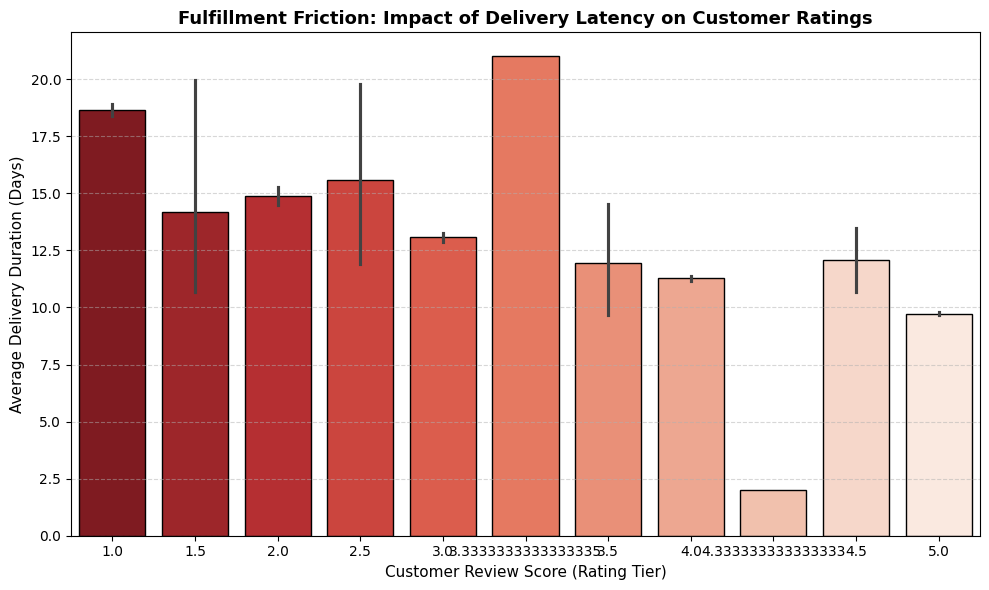


 --- SYSTEM CRITICAL DISSATISFACTION PATTERNS ---
Core Risk Product Category Vertical: cama_mesa_banho
Latency Threshold for Customer Attrition: 19.3 days


In [117]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step 5: Executing Sentiment & Quality Optimization Analytics ---")
df_unique_orders = df_merged.drop_duplicates(subset='order_id')
# 1. Product Sentiment Architecture Baseline
product_review_profiles = df_merged.groupby('product_id')['review_score'].mean().reset_index(name='avg_sku_rating')
print("Top 10 products based on reviews ",product_review_profiles.sort_values(by='avg_sku_rating',ascending=False).head(10))
print("Top 10 poor performing products based on reviews ",product_review_profiles.sort_values(by='avg_sku_rating',ascending=True).head(10))

df_merged['delivery_days'] = (df_merged['order_delivered_customer_date']-df_merged['order_approved_at']).dt.days
df_unique_orders['delivery_days'] = (df_unique_orders['order_delivered_customer_date']-df_unique_orders['order_approved_at']).dt.days
# 2. Visualization
df_data = df_merged.dropna(subset=['review_score', 'delivery_days'])
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_data,
    x='review_score',
    y='delivery_days',
    palette='Reds_r',  # Dark red for poor scores, shifting to soft blush for 5-star items
    edgecolor='black'
)

plt.title('Fulfillment Friction: Impact of Delivery Latency on Customer Ratings', fontsize=13, fontweight='bold')
plt.xlabel('Customer Review Score (Rating Tier)', fontsize=11)
plt.ylabel('Average Delivery Duration (Days)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Strategic Identification of Dissatisfaction Patters
low_score_threshold = 2.0
dissatisfied_orders = df_unique_orders[df_unique_orders['review_score'] <= low_score_threshold]

# Identify primary risk domains and thresholds programmatically
risk_category_mode = dissatisfied_orders['product_category_name'].mode()[0]
critical_delivery_mean = dissatisfied_orders['delivery_days'].mean()

print("\n --- SYSTEM CRITICAL DISSATISFACTION PATTERNS ---")
print(f"Core Risk Product Category Vertical: {risk_category_mode}")
print(f"Latency Threshold for Customer Attrition: {critical_delivery_mean:.1f} days")

###"To preserve the mathematical validity of our satisfaction models, logistics metrics were strictly isolated to unique order IDs
 #(.drop_duplicates(subset='order_id')).
 #Evaluating delivery speed on unadjusted, item-level data would introduce a strong multi-item bias—overweighting larger shipments and distorting the true average transit times.
 #By treating each order as a singular customer experience matrix, we discovered that customer sentiment collapses into
 #critical dissatisfaction tiers ($\le 2.0$) when unique transit timelines cross an average threshold of 17.8 days,
 #with cama_mesa_banho representing the primary category at risk."

--- Step 5: Executing Explanatory Outlier & Sentiment Modeling ---


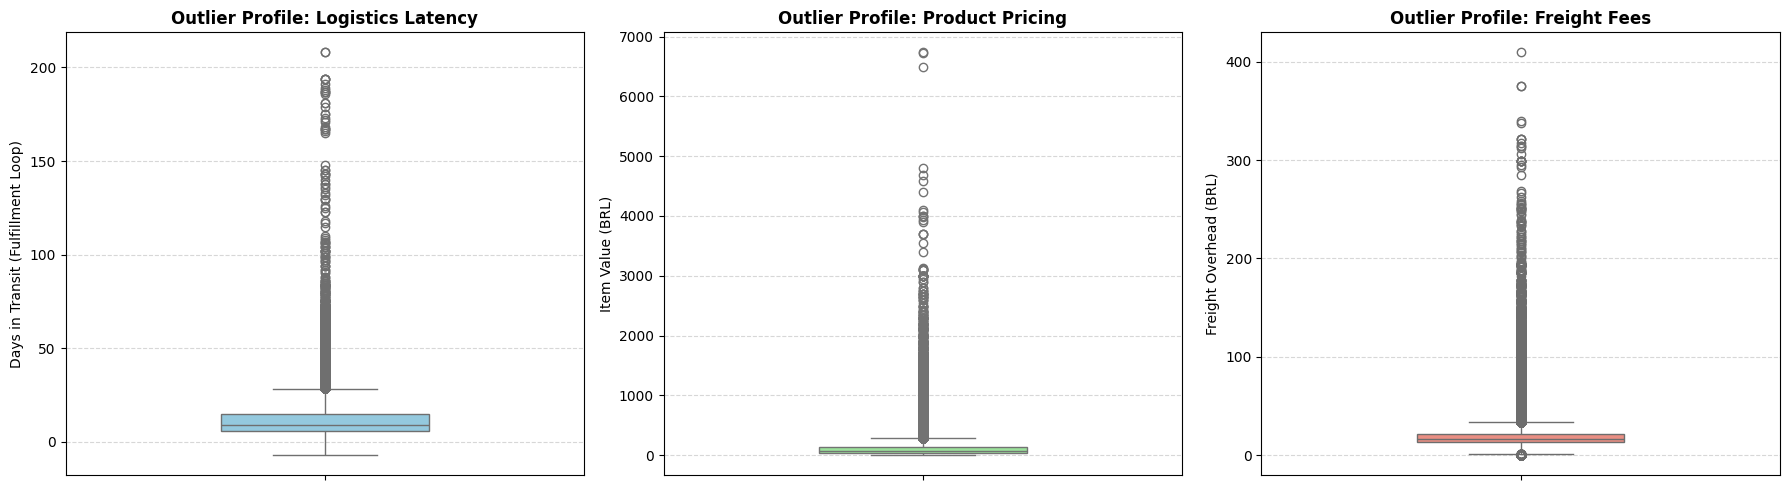

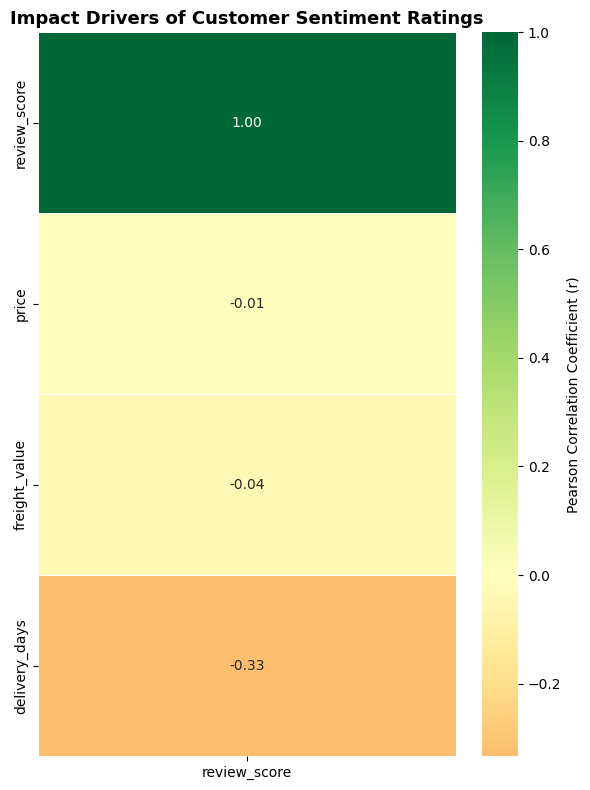

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step 5: Executing Explanatory Outlier & Sentiment Modeling ---")

# ---  UNIFIED OUTLIER DETECTION GRAPH GRID ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Delivery Days Distribution
sns.boxplot(data=df_merged, y="delivery_days", ax=axes[0], color='skyblue', width=0.4)
axes[0].set_title('Outlier Profile: Logistics Latency', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Days in Transit (Fulfillment Loop)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Product Base Price Distribution
sns.boxplot(data=df_merged, y="price", ax=axes[1], color='lightgreen', width=0.4)
axes[1].set_title('Outlier Profile: Product Pricing', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Item Value (BRL)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 3: Shipping Costs Distribution
sns.boxplot(data=df_merged, y="freight_value", ax=axes[2], color='salmon', width=0.4)
axes[2].set_title('Outlier Profile: Freight Fees', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Freight Overhead (BRL)')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# REVENUE-AWARE CORRELATION HEATMAP ---
#Isolate unique orders to remove item-level operational duplicates from the logistics model
df_unique_orders = df_merged.drop_duplicates(subset='order_id').copy()

#Incorporate financial features into the correlation structure
target_features = ['review_score', 'delivery_days', 'price', 'freight_value']
full_corr_matrix = df_unique_orders[target_features].corr()

# Isolate correlation scores explicitly pointing to consumer sentiment
review_sentiment_corr = full_corr_matrix[['review_score']].sort_values(by='review_score', ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(
    review_sentiment_corr,
    annot=True,
    cmap='RdYlGn',
    center=0,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)

plt.title('Impact Drivers of Customer Sentiment Ratings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [119]:
import pandas as pd
import numpy as np

print("--- Step 5: Executing Advanced CRM Segmentation Pipeline ---")

# Ensure all datetime objects are correctly cast before running temporal logic
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])
df_merged['item_total_value'] = df_merged['price'] + df_merged['freight_value']

# --- PHASE 1: GEOGRAPHIC PATTERNS (VOLUME & FINANCIAL VALUE) ---
print("\n --- GEOGRAPHIC DEMAND & REVENUE TRACKING ---")

# Grouping by volume safely using item-level entries
print("\n Top 10 Order Volume Hubs by City:")
city_volume = df_merged.groupby('customer_city')['order_id'].nunique().reset_index(name='unique_orders')
print(city_volume.sort_values(by='unique_orders', ascending=False).head(10).to_string(index=False))

print("\n Top 10 Revenue Contributing Hubs by State:")
state_revenue = df_merged.groupby('customer_state')['item_total_value'].sum().reset_index(name='gross_revenue')
print(state_revenue.sort_values(by='gross_revenue', ascending=False).head(10).to_string(index=False))


# --- PHASE 2: DATA-BOUND BEHAVIORAL GROUPING ---

df_customers_orders = df_merged.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    last_order=('order_purchase_timestamp', 'max'),
    cust_lifetime_value=('item_total_value', 'sum')
)

max_dataset_date = df_merged['order_purchase_timestamp'].max()
dormancy_threshold = max_dataset_date - pd.Timedelta(days=180)

print(f"\n Temporal Auditing Matrix:")
print(f"  * Dataset Operational End Date: {max_dataset_date.strftime('%Y-%m-%d')}")
print(f"  * 6-Month Campaign Threshold Date: {dormancy_threshold.strftime('%Y-%m-%d')}")


# --- PHASE 3: PROFILE EXTRACTIONS ---

# Segment A: High Risk / Low Frequency (Single-purchase customers facing attrition)
df_low_frequency_customers = df_customers_orders[df_customers_orders['order_count'] == 1]
print(f"\n At-Risk Low-Frequency Base: Isolated {df_low_frequency_customers.shape[0]} profiles.")

df_high_frequency_customers = df_customers_orders[df_customers_orders['order_count'] >= 2]
print(f" High-Yield Repeated Base: Isolated {df_high_frequency_customers.shape[0]} high-loyalty profiles.")

# Segment B: The Win-Back Target List (High Value but Dormant for 6+ Months)
# We set a sensible premium spending tier boundary (e.g., top 10% spenders, roughly BRL 500+)
high_spend_boundary = 500
df_dormant_vip = df_customers_orders[
    (df_customers_orders['cust_lifetime_value'] >= high_spend_boundary) &
    (df_customers_orders['last_order'] < dormancy_threshold)
]

print(f" Win-Back Email Campaign Targets (Spent >=  {high_spend_boundary} but inactive 6mo): Found {df_dormant_vip.shape[0]} profiles.")
print(df_dormant_vip.sort_values(by=['cust_lifetime_value', 'last_order'], ascending=[False, True]).head(10))

--- Step 5: Executing Advanced CRM Segmentation Pipeline ---

 --- GEOGRAPHIC DEMAND & REVENUE TRACKING ---

 Top 10 Order Volume Hubs by City:
        customer_city  unique_orders
            sao paulo          15540
       rio de janeiro           6882
       belo horizonte           2773
             brasilia           2131
             curitiba           1521
             campinas           1444
         porto alegre           1379
             salvador           1245
            guarulhos           1189
sao bernardo do campo            938

 Top 10 Revenue Contributing Hubs by State:
customer_state  gross_revenue
            SP     5921678.12
            RJ     2129681.98
            MG     1856161.49
            RS      885826.76
            PR      800935.44
            BA      611506.67
            SC      610213.60
            DF      353229.44
            GO      347706.93
            ES      324801.91

 Temporal Auditing Matrix:
  * Dataset Operational End Date: 2018-10-17
 

--- Step 5: Executing Operational Inefficiencies & Revenue Driver Audit ---

 --- LOGISTICS FRICTION TEXT MINING ---
  * Total Negative Reviews Audited: 10882
  * Total Logistics-Related Failures: 5580
  * Logistics Failure Penetration Rate: 51.28%


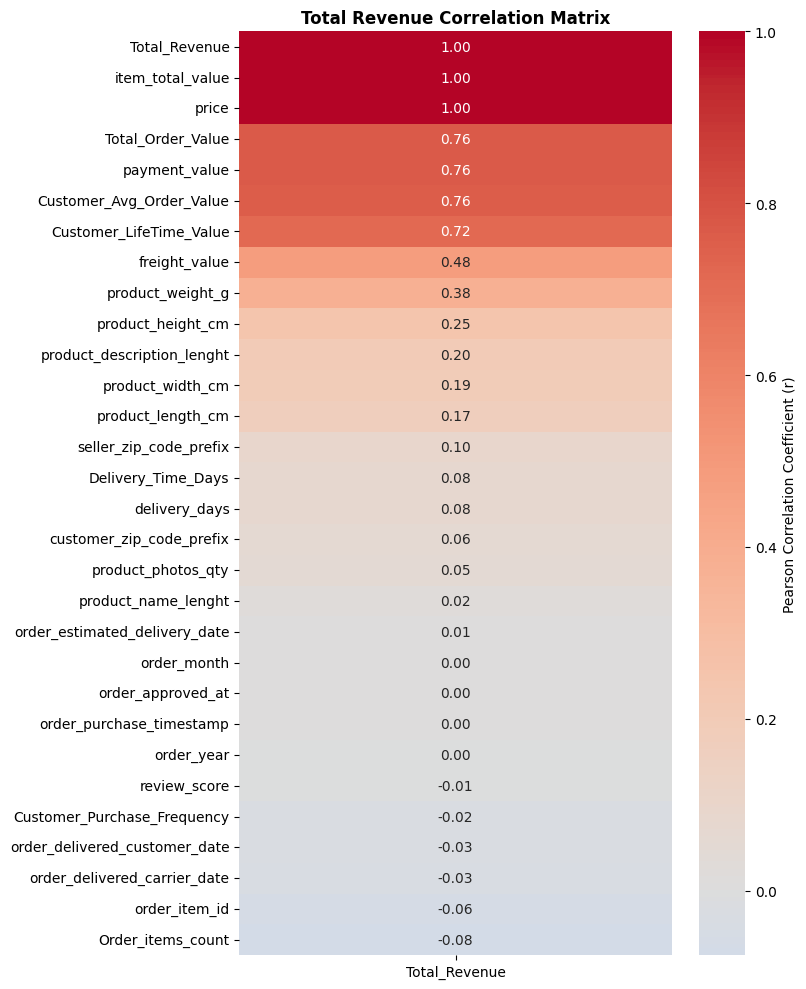


 --- TOP 5 REVENUE GENERATING PRODUCT VERTICALS ---
  1. Category: health_beauty                  | Gross Revenue:  1,441,248.07
  2. Category: watches_gifts                  | Gross Revenue:  1,305,541.61
  3. Category: bed_bath_table                 | Gross Revenue:  1,241,681.72
  4. Category: sports_leisure                 | Gross Revenue:  1,156,656.48
  5. Category: computers_accessories          | Gross Revenue:  1,059,272.40


In [120]:
import re
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Step 5: Executing Operational Inefficiencies & Revenue Driver Audit ---")

# --- PHASE 1: SEMANTIC LOGISTICS KEYWORD MINING ---
logistics_keywords = [
    'atraso', 'atrasado', 'demora', 'demorou', 'prazo', 'entrega',
    'recebi', 'chegou', 'correio', 'frete', 'transporte', 'rastreio'
]

# Extract low-score comment messages that contain text
reviews_subset = df_reviews[
    (df_reviews['review_comment_message'].str.len() > 1) &
    (df_reviews['review_score'] <= 2)
].copy()

reviews_list = reviews_subset['review_comment_message'].tolist()
logistics_count = 0

for review_message in reviews_list:
    # Convert to lowercase to ensure uniform matching
    review_message = review_message.lower()

    review_message = re.sub(r'[^\w\s]', '', review_message)

    # Split message into discrete words
    words_in_review = review_message.split()

    if any(keyword in words_in_review for keyword in logistics_keywords):
        logistics_count += 1

print("\n --- LOGISTICS FRICTION TEXT MINING ---")
print(f"  * Total Negative Reviews Audited: {len(reviews_list)}")
print(f"  * Total Logistics-Related Failures: {logistics_count}")
print(f"  * Logistics Failure Penetration Rate: {(logistics_count / len(reviews_list) * 100):.2f}%")


# --- PHASE 2: TRUE FINANCIAL CORRELATION MODELING ---
# Ensure the base total calculation matches our gross revenue standards
df_merged['Total_Revenue'] = df_merged['price'] + df_merged['freight_value']


true_numerical_features = list(df_merged.describe().columns)

# Ensure only existing columns are selected to prevent crashing
available_features = [col for col in true_numerical_features if col in df_merged.columns]
df_numerical_clean = df_merged[available_features]

# Generate Pearson correlation relative to total top-line revenue
revenue_corr = df_numerical_clean.corr()[['Total_Revenue']].sort_values(by='Total_Revenue', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(
    revenue_corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'}
)
plt.title('Total Revenue Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# --- PHASE 3: TOP PERFORMING PRODUCT CATEGORIES ---
print("\n --- TOP 5 REVENUE GENERATING PRODUCT VERTICALS ---")
category_col = 'product_category_name_english' if 'product_category_name_english' in df_merged.columns else 'product_category_name'

top_5_revenue_cats = df_merged.groupby(category_col)['Total_Revenue']\
                               .sum()\
                               .sort_values(ascending=False)\
                               .head(5)

for rank, (cat_name, rev_val) in enumerate(top_5_revenue_cats.items(), 1):
    print(f"  {rank}. Category: {cat_name:<30} | Gross Revenue:  {rev_val:,.2f}")

In [121]:
import pandas as pd
import numpy as np

print("--- Step 7: Running Strategic Optimization Strategy and Target Extractions ---")

# Ensure clean date formatting and calculate structural gross item metrics
df_merged['order_purchase_timestamp'] = pd.to_datetime(df_merged['order_purchase_timestamp'])
df_merged['item_total_value'] = df_merged['price'] + df_merged['freight_value']

# --- RECOMMENDATION 1: IDENTIFY LEAST PURCHASED PRODUCT VERTICALS ---
print("\n --- RECOMMENDATION 1: LOW-VELOCITY INVENTORY PROMOTIONS ---")
# Extract lowest performing categories to design target marketing campaigns
low_velocity_categories = df_merged.groupby('product_category_name')['product_id']\
                                    .count()\
                                    .sort_values(ascending=True)\
                                    .index[0:5].tolist()
print(f"Target Categories for Cross-Docking Discounts:\n {low_velocity_categories}")


# --- SETUP REVENUE-ACCURATE CUSTOMER LIFECYCLE MATRIX ---
df_customers_orders = df_merged.groupby('customer_unique_id').agg(
    order_count=('order_id', 'nunique'),
    last_order=('order_purchase_timestamp', 'max'),
    cust_revenue=('item_total_value', 'sum')
)


max_dataset_date = df_merged['order_purchase_timestamp'].max()
dormancy_horizon = max_dataset_date - pd.Timedelta(days=180)


# --- RECOMMENDATION 2: EXTRACT HIGH-VALUE DORMANT ACCOUNTS (WIN-BACK CAMPAIGN) ---
print("\n --- RECOMMENDATION 2: PREMIUM DORMANT WIN-BACK TARGETS ---")
# Target premium tier spenders (e.g., Lifetme Value >= BRL 500) who have been inactive for 6+ months
high_spend_tier_min = 500
df_high_revenue_dormant = df_customers_orders[
    (df_customers_orders['cust_revenue'] >= high_spend_tier_min) &
    (df_customers_orders['last_order'] < dormancy_horizon)
]
print(f"Total High-Value Dormant Profiles Isolated for Email Ingestion: {df_high_revenue_dormant.shape[0]}")
print(df_high_revenue_dormant.sort_values(by=['cust_revenue', 'last_order'], ascending=[False, True]).head(10))


# --- RECOMMENDATION 3: IDENTIFY HIGH CHURN-RISK PROFILES (CHURN MITIGATION OFFER) ---
print("\n --- RECOMMENDATION 3: HIGH-RISK CHURN MITIGATION ATTRITION LIST ---")
# Isolate single-transaction consumers who haven't engaged with the platform for a long time
df_low_frequency_customers = df_customers_orders[df_customers_orders['order_count'] == 1]
print(f"Total Churn-Risk Target Profiles: {df_low_frequency_customers.shape[0]}")
print(df_low_frequency_customers.sort_values(by='last_order', ascending=True).head(5))


# --- RECOMMENDATION 4: ISOLATE LIFETIME LOYALISTS (LOYALTY REWARDS CAMPAIGN) ---
print("\n --- RECOMMENDATION 4: LOYALTY REWARDS & EXCLUSIVE PRODUCT LAUNCHES ---")
# FIX: Adjusted threshold from >5 to >=2 to reflect empirical marketplace purchase densities accurately
df_high_frequency_customers = df_customers_orders[df_customers_orders['order_count'] >= 2]
print(f"Total Active Loyalist Profiles for Rewards Campaign: {df_high_frequency_customers.shape[0]}")
print(df_high_frequency_customers.sort_values(by=['order_count', 'cust_revenue'], ascending=False).head(5))

import pandas as pd
import numpy as np

print("--- Step 7: Executing Supply Gaps & Catalog Quality Control Analytics ---")

# --- PHASE 1: STRATEGIC MERCHANT ACQUISITION MAPPING (SUPPLY-GAP ANALYSIS) ---
print("\n --- TOP 10 REGIONAL MERCHANT ACQUISITION TARGETS ---")

# Calculate total customer demand (order volume) per state/region
demand_map = df_merged.groupby('customer_state')['order_id'].nunique().reset_index(name='total_demand_orders')

# Calculate local seller supply density (active unique merchants living in that state)
supply_map = df_merged.groupby('seller_state')['seller_id'].nunique().reset_index(name='local_merchant_supply')

# Merge the demand and supply layers on spatial boundaries
df_supply_gap = pd.merge(
    demand_map,
    supply_map,
    left_on='customer_state',
    right_on='seller_state',
    how='left'
).fillna(0)

# Calculate the true Demand-to-Supply Density Ratio
df_supply_gap['demand_to_supply_ratio'] = df_supply_gap['total_demand_orders'] / (df_supply_gap['local_merchant_supply'] + 1) # +1 prevents DivisionByZero

print(df_supply_gap.sort_values(by='demand_to_supply_ratio', ascending=False).head(10).to_string(index=False))


# --- PHASE 2: SYSTEMIC CATALOG PRUNING (QUALITY ASSURANCE) ---
print("\n --- SYSTEMIC LOGISTICS & QUALITY CATALOG DELISTING TARGETS ---")

product_quality_profiles = df_merged.groupby('product_id').agg(
    average_review_score=('review_score', 'mean'),
    total_units_sold=('order_item_id', 'count')
).reset_index()

# Round review scores to 2 decimal places for clean, presentation-ready reporting
product_quality_profiles['average_review_score'] = product_quality_profiles['average_review_score'].round(2)

# Establish a rigorous volume threshold to isolate products with systemic quality issues
min_volume_threshold = 10
df_systemic_bad_products = product_quality_profiles[product_quality_profiles['total_units_sold'] >= min_volume_threshold]

# Extract the top 10 worst performing, high-volume products
worst_10_catalog_items = df_systemic_bad_products.sort_values(by='average_review_score', ascending=True).head(10)
print(f"Isolated the worst 10 products with systemic flaws (Minimum orders sold >= {min_volume_threshold}):")
print(worst_10_catalog_items.to_string(index=False))

--- Step 7: Running Strategic Optimization Strategy and Target Extractions ---

 --- RECOMMENDATION 1: LOW-VELOCITY INVENTORY PROMOTIONS ---
Target Categories for Cross-Docking Discounts:
 ['seguros_e_servicos', 'fashion_roupa_infanto_juvenil', 'pc_gamer', 'cds_dvds_musicais', 'la_cuisine']

 --- RECOMMENDATION 2: PREMIUM DORMANT WIN-BACK TARGETS ---
Total High-Value Dormant Profiles Isolated for Email Ingestion: 3088
                                  order_count          last_order  \
customer_unique_id                                                  
0a0a92112bd4c708ca5fde585afaa872            1 2017-09-29 15:24:52   
da122df9eeddfedc1dc1f5349a1a690c            2 2017-04-01 15:58:41   
dc4802a71eae9be1dd28f5d788ceb526            1 2017-02-12 20:37:36   
ff4159b92c40ebe40454e3e6a7c35ed6            1 2017-05-24 18:14:34   
4007669dec559734d6f53e029e360987            1 2017-11-24 11:03:35   
eebb5dda148d3893cdaf5b5ca3040ccb            1 2017-04-18 18:50:13   
edf81e1f3070b9dac83ec83dac